In [2]:
import time

import numpy as np
import torchvision
import torch
import matplotlib.pyplot as plt

import util


## Non-overlapping permutations algorithm

We want to find an algorithm to generate N random permutations with non-overlapping items. The current implementation searches randomly until it finds suitable permutations, which might have infinite running time

In [3]:

def no_overlap_perms_random(n, length, max_seconds=10, return_elapsed=False):
    """ Returns n random permutations of range(length) without overlaps using randomness (potential infinite runtime) """
    start = time.time()
    no_overlap_perms = []

    for depth in range(n):
        while ...:
            rand_perm = np.random.permutation(np.arange(length))
            if all(not 0 in p - rand_perm for p in no_overlap_perms):
                break
            elif max_seconds:
                if time.time() - start > max_seconds:
                    print("non overlapping ordering search took too long")
                    return ([], time.time() - start) if return_elapsed else []
        no_overlap_perms.append(rand_perm)
    return (no_overlap_perms, time.time() - start) if return_elapsed else no_overlap_perms


In [4]:
no_overlap_perms_random(3, 10, return_elapsed=True)

([array([7, 1, 2, 3, 6, 0, 4, 8, 5, 9]),
  array([1, 4, 9, 6, 2, 3, 7, 5, 0, 8]),
  array([5, 8, 3, 2, 9, 4, 0, 6, 7, 1])],
 0.004076242446899414)

## Mix-up data for any N

In [5]:

def mixup_data(n_ways, X, y, lam_):
    """
    Mixes data n ways with itself shuffled without overlaps, returns X_mixed and an array of every y shuffling
    Example:
        mixup_data(3, X, y, (.5, .5, 0)) will return X_mixed, y[permutation0], y[permutation1], y[permutation2]
        and X_mixed will veriy X_mixed = .5*X[permutation0] + .5*X[permutation1] + 0*X[permutation2]
    X: np.arr of shape (batch_size, w, h)
    y: np.arr of shape (batch_size,)
    lam_: np.arr of shape (n_ways, )
    """
    assert lam_.shape[0] == n_ways
    assert X.shape[0] == y.shape[0]
    assert lam_.sum() == 1
    lam_rs = lam_.reshape((n_ways, 1, 1, 1, 1))
    perms = util.no_overlap_perms_random(n_ways, X.shape[0])
    X_permutations = np.array([X[perm] for perm in perms])
    X_mixed = (X_permutations * lam_rs).sum(axis=0)
    ys = [y[perm] for perm in perms]
    return X_mixed, ys, perms
    

In [6]:
BATCH_SIZE, NUM_WORKERS = 50, 1
transform = torchvision.transforms.transforms.Compose([torchvision.transforms.transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='datasets', train=False, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Files already downloaded and verified
Files already downloaded and verified


#### Original images

In [8]:
X, y = [np.array(next(iter(trainloader))[i]) for i in [0, 1]]

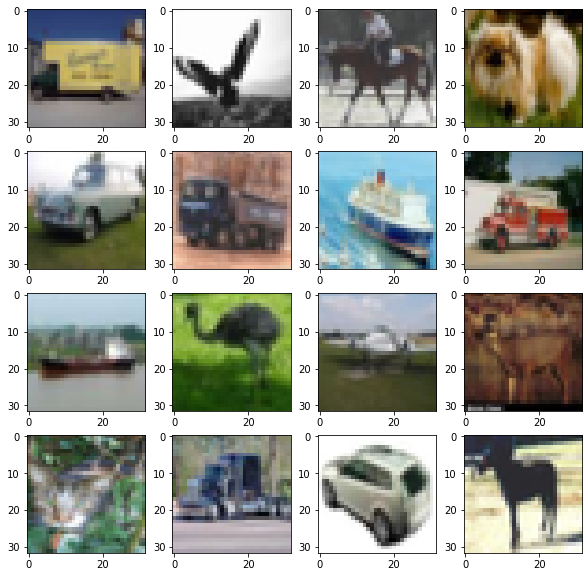

In [33]:
plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4, 4, i+1)
    util.show_np_array(X[i])

#### Using it with N=2 to check if it does the same thing

In [30]:
lambda_v = np.array([.5, .5])
X_mixup, ys, perms = mixup_data(2, X, y, lambda_v)

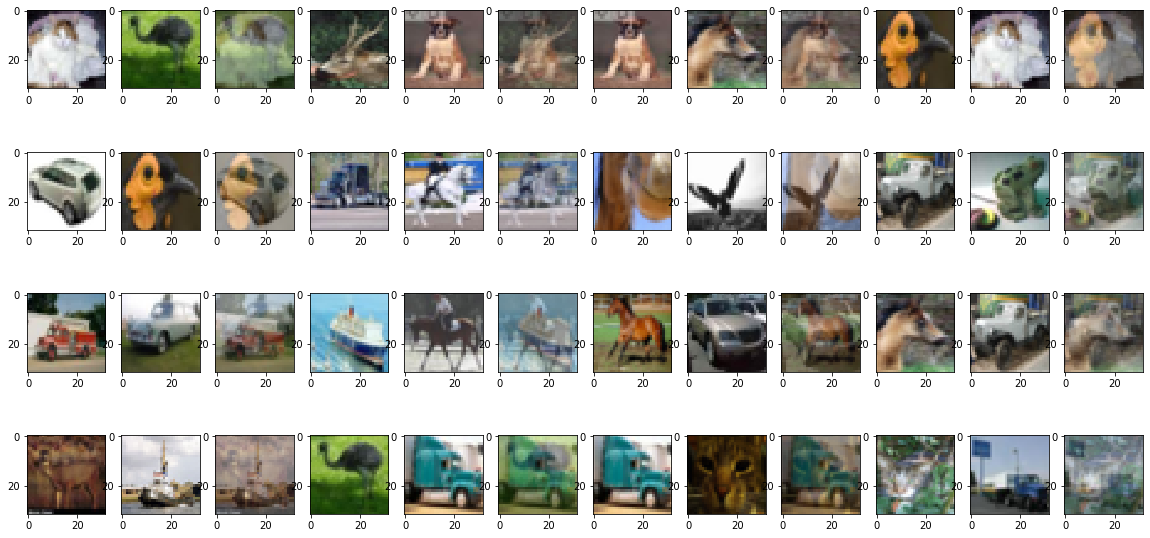

In [32]:
plt.figure(figsize=(20,10))

for i in range(16):
    plt.subplot(4, 12, 3*i+1)
    util.show_np_array(X[perms[0]][i])
    plt.subplot(4, 12, 3*i+2)
    util.show_np_array(X[perms[1]][i])
    plt.subplot(4, 12, 3*i+3)
    util.show_np_array(X_mixup[i])

#### N=3

In [10]:
lambda_v3 = np.array([.75, .2, .05])
X_mixup3, ys3, perms3 = mixup_data(3, X, y, lambda_v3)

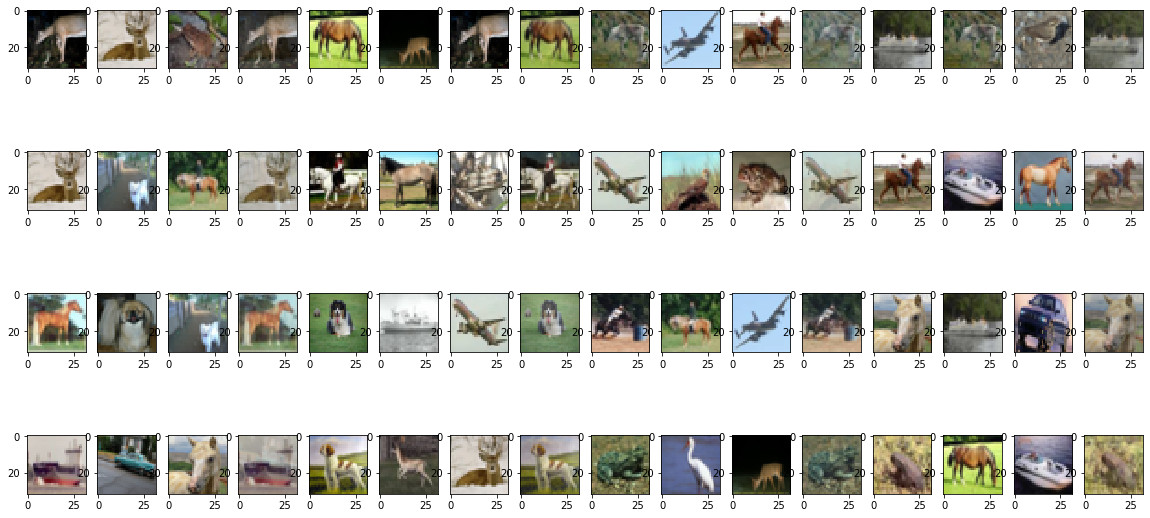

In [11]:
plt.figure(figsize=(20,10))

for i in range(16):
    plt.subplot(4, 16, 4*i+1)
    util.show_np_array(X[perms3[0]][i])
    plt.subplot(4, 16, 4*i+2)
    util.show_np_array(X[perms3[1]][i])
    plt.subplot(4, 16, 4*i+3)
    util.show_np_array(X[perms3[2]][i])
    plt.subplot(4, 16, 4*i+4)
    util.show_np_array(X_mixup3[i])

#### N=4

In [23]:
lambda_v4 = np.array([.25, .25, .25, .25])
X_mixup4, ys4, perms4 = mixup_data(4, X, y, lambda_v4)

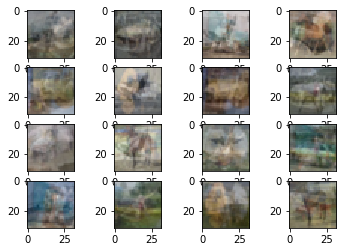

In [24]:
for i in range(16):
    plt.subplot(4, 4, i+1)
    util.show_np_array(X_mixup4[i])

## Loss with N>2

We now have N instead of 2 predictions and ys, we apply the exact same principle that we use with N=2.

In [35]:

def mixup_criterion(criterion, preds, ys, lambda_v):
    return [lambda_v[i] * criterion(preds[i], ys[i]) for i in range(lambda_v.shape[0])]

## Goals

Currently:
 - get results on CIFAR10 with N>2, try to find if some "good lambdas" also exist for N>2
 
Subgoals:
 - implement tensorboard data collection to observe Loss progression rates
 - find more efficient permutations algorithm?

* Test only same class on lambdas
* Test half weights each index normalized to 1

* Try uniform weights see if as good no mixup